In [2]:

# Adding noise to the basic broadcasting protocol from Hillery et al

import numpy as np
import warnings
import itertools
from math import comb
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.io as pio
warnings.filterwarnings('ignore')
np.set_printoptions(linewidth=500)
np.set_printoptions(precision=3, suppress=True)
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix, Operator, Statevector, Pauli, partial_trace, state_fidelity


In [3]:
# Creating the M senders N receivers broadcasting protocol

# Partial trace implementation for numpy arrays
def partial_trace_np(rho, dims, keep):
    """
    Partial trace for a density matrix `rho` (numpy 2D array) over a product space
    with local dimensions `dims` (e.g., (3,2,2) for qutrit⊗qubit⊗qubit).
    `keep` is a list of subsystem indices to keep (e.g., [1] to keep Bob).

    Returns a numpy 2D array for the reduced density matrix on the kept subsystems.
    """
    dims = list(dims)
    N = len(dims)
    keep = sorted(keep)
    trace_out = [i for i in range(N) if i not in keep]

    # reshape ρ → rank-2N tensor with one index per subsystem on bra and ket
    rho = rho.data
    rho_t = rho.reshape(dims + dims)  # indices: (a,b,c, a',b',c') for dims=(3,2,2)

    # trace out each unwanted subsystem: contract axis s with its paired axis s+N
    for s in sorted(trace_out, reverse=True):
        rho_t = np.trace(rho_t, axis1=s, axis2=s+len(dims))
        dims.pop(s)

    # collapse back to a matrix on the kept subsystems
    d_kept = int(np.prod(dims)) if dims else 1
    return rho_t.reshape(d_kept, d_kept)

def get_initial_state(M, N, alpha=1/np.sqrt(2)):
    """
    Construct the state |Psi^{(M,N)}> as a complex vector.

    Parameters
    ----------
    M : int
        Number of qudits
    N : int
        Number of qubits
    alpha : complex
        Amplitude parameter (|alpha| <= 1)

    Returns
    -------
    state : np.ndarray
        Complex state vector of size (N+1)^M * 2^N
    """

    beta = np.sqrt(1 - abs(alpha)**2)

    d_qudit = N + 1
    dim_qudits = d_qudit ** M
    dim_qubits = 2 ** N
    dim_total = dim_qudits * dim_qubits

    state = np.zeros(dim_total, dtype=complex)

    def qudit_index(k):
        """Index for |k>^{⊗M}"""
        idx = 0
        for _ in range(M):
            idx = idx * d_qudit + k
        return idx

    def qubit_index(bitstring):
        """Binary index"""
        idx = 0
        for b in bitstring:
            idx = (idx << 1) | b
        return idx

    for k in range(N + 1):
        coeff = (alpha**k) * (beta**(N - k)) * np.sqrt(comb(N, k))

        qd_idx = qudit_index(k)

        # Generate all symmetric qubit basis states
        for zeros in itertools.combinations(range(N), k):
            bits = [1] * N
            for z in zeros:
                bits[z] = 0

            qb_idx = qubit_index(bits)

            full_idx = qd_idx * dim_qubits + qb_idx
            state[full_idx] += coeff / np.sqrt(comb(N, k))

    return Statevector(state)
    
def depolarizing_channels(M, N, rho, p_list):
    """Apply a depolarizing channel with probabilities in p_list to each receiver's qubit in density matrix rho."""
    rho_mat = rho.data
    total_receivers = len(p_list)
    for i, p in enumerate(p_list):
        # Applying to i-th receiver's qubit
        evolve_x = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('X').to_matrix())
        evolve_x = np.kron(evolve_x, np.eye(2**(total_receivers - i - 1)))
        
        evolve_y = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('Y').to_matrix())
        evolve_y = np.kron(evolve_y, np.eye(2**(total_receivers - i - 1)))
        
        evolve_z = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('Z').to_matrix())
        evolve_z = np.kron(evolve_z, np.eye(2**(total_receivers - i - 1)))
        
        rho_mat = (1 - p) * rho_mat + (p / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                                 evolve_y @ rho_mat @ evolve_y.conj().T +
                                                 evolve_z @ rho_mat @ evolve_z.conj().T)
    return rho_mat

def apply_alice_unitaries(M, N, rho, theta_list):
    rho_mat = rho.data
    theta_list = np.asarray(theta_list, dtype=float)

    # Single-Alice diagonal phases over k=0..N
    k = np.arange(N+1, dtype=float)
    single = [np.diag(np.exp(1j * (2.0 * k - float(N)) * theta_list[j])) for j in range(M)]

    # U_A = ⊗_j U_{a_j}
    U_A = single[0]
    for j in range(1, M):
        U_A = np.kron(U_A, single[j])

    # Extend with identity on N receiver qubits
    I_R = np.eye(2 ** N, dtype=complex)
    U = np.kron(U_A, I_R)

    # Apply to density matrix
    rhoU =  U @ rho_mat @ U.conj().T
    return DensityMatrix(rhoU)

def measure_alices(M, N, rho, outcomes_list=None):
    rho_mat = rho.data
    
    d = N + 1
    I_R = np.eye(2**N, dtype=complex)

    # Precompute Fourier-basis kets |u_n> and single-qudit projectors P_n = |u_n><u_n|
    k = np.arange(d)
    u_kets = []
    for n in range(d):
        phases = np.exp(2j * np.pi * n * k / d)
        u = phases / np.sqrt(d)
        u_kets.append(u.astype(complex))

    P_single = [np.outer(u, np.conj(u)) for u in u_kets]  # list of (d,d) projectors

    rng = np.random.default_rng()
    outcomes = []

    # Measure Alice j sequentially (equivalent to a joint projective measurement here)
    for j in range(M):
        left_dim = d**j
        right_dim = (d**(M - j - 1)) * (2**N)

        I_left = np.eye(left_dim, dtype=complex)
        I_right = np.eye(right_dim, dtype=complex)

        if outcomes_list is None:
            # Compute probabilities p(n) = Tr(Π_n rho) for n=0..N
            probs = np.empty(d, dtype=float)
            for n in range(d):
                Pi = np.kron(I_left, np.kron(P_single[n], I_right))
                probs[n] = float(np.real(np.trace(Pi @ rho_mat)))
            probs = probs / probs.sum()
            n_out = int(rng.choice(d, p=probs))
        else:
            n_out = int(outcomes_list[j])

        outcomes.append(n_out)

        # Apply projection and renormalize: rho <- Π rho Π / Tr(Π rho)
        Pi = np.kron(I_left, np.kron(P_single[n_out], I_right))
        p = np.trace(Pi @ rho_mat)
        rho_mat = (Pi @ rho_mat @ Pi) / p
    # print("Measurement outcomes:", outcomes)
    return DensityMatrix(rho_mat), outcomes

def apply_corrections(M, N, rho, outcomes_list):
    rho_mat = rho.data
    d = N + 1
    outcomes_list = np.asarray(outcomes_list, dtype=int)

    # Phase determined by the broadcast outcomes
    phi = 2.0 * np.pi * outcomes_list.sum() / d

    # Single-qubit correction on each receiver
    U1 = np.array([[np.exp(1j * phi), 0.0],
                   [0.0,            1.0]], dtype=complex)

    # Build (U1)^{⊗ N}
    UR = U1
    for _ in range(1, N):
        UR = np.kron(UR, U1)

    # Full unitary: identity on Alices, UR on receivers
    UA_id = np.eye(d**M, dtype=complex)
    U = np.kron(UA_id, UR)

    rho_mat =  U @ rho_mat @ U.conj().T

    return DensityMatrix(rho_mat)

def M_N_broadcasting_with_depolarizing(M, N, alpha_val=1/np.sqrt(2), theta_list=None, p_list=None, outcomes_list=None):
    rho = DensityMatrix(get_initial_state(M=M, N=N))

    noisy_rho = depolarizing_channels(M=M, N=N, rho=rho, p_list=p_list)
    final_rho = apply_alice_unitaries(M=M, N=N, rho=noisy_rho, theta_list=theta_list)

    post_measurement_rho, outcomes = measure_alices(M=M, N=N, rho=final_rho, outcomes_list=outcomes_list)

    corrected_rho = apply_corrections(M=M, N=N, rho=post_measurement_rho, outcomes_list=outcomes)
    
    # Getting each receiver's reduced density matrices
    reduced_states = []
    for receiver_idx in range(N):
        reduced_states.append(DensityMatrix(partial_trace_np(corrected_rho, dims=( (N+1)**M, ) + (2,)*N, keep=[receiver_idx +1])))  # 2×2
    
    # Getting the fidelities
    fidelities = []
    beta_val = np.sqrt(1 - alpha_val**2)
    theta_total = np.sum(theta_list)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_total), beta_val * np.exp(-1j*theta_total)] )
    for receiver_state in reduced_states:
        fidelities.append( state_fidelity(receiver_state, DensityMatrix(target_state)) )
    
    return (fidelities, target_state, reduced_states)


# Error correction versions

def encode_initial_state(state, M, N):
    """
    Encode each receiver qubit of |Psi^{(M,N)}> into 5 physical qubits
    using the [[5,1,3]] perfect code.

    Assumptions / conventions
    -------------------------
    - `state` is a qiskit Statevector with dimension (N+1)^M * 2^N
    - Basis ordering matches get_initial_state():
        * sender qudits first (base d=N+1, big-endian across M qudits)
        * then receiver qubits (big-endian bitstring order)
    - Returns a new Statevector with dimension (N+1)^M * 2^(5N)

    Parameters
    ----------
    state : qiskit.quantum_info.Statevector
        Unencoded state vector.
    M : int
        Number of senders (qudits).
    N : int
        Number of receivers (logical qubits before encoding).

    Returns
    -------
    qiskit.quantum_info.Statevector
        Encoded state vector with 5 physical qubits per receiver.
    """
    d = N + 1
    expected_dim = (d ** M) * (2 ** N)

    # Extract raw vector
    vec = np.asarray(state.data if hasattr(state, "data") else state, dtype=complex)

    if vec.ndim != 1:
        raise ValueError("Input `state` must be a flat state vector (1D array / Statevector).")
    if vec.size != expected_dim:
        raise ValueError(
            f"Input state dimension mismatch: got {vec.size}, expected {expected_dim} = (N+1)^M * 2^N"
        )

    # ------------------------------------------------------------------
    # [[5,1,3]] perfect code logical basis |0_L>, |1_L> in computational basis
    # Basis order is |b1 b2 b3 b4 b5> with binary index b1..b5 (big-endian),
    # matching your qubit_index convention.
    # ------------------------------------------------------------------
    v0 = np.zeros(32, dtype=complex)

    # Terms for |0_L> with coefficients ±1/4
    plus_terms = [
        "00000", "10010", "01001", "10100", "01010", "00101"
    ]
    minus_terms = [
        "11011", "00110", "11000", "11101", "00011",
        "11110", "01111", "10001", "01100", "10111"
    ]

    def bits_to_index(bitstr):
        idx = 0
        for ch in bitstr:
            idx = (idx << 1) | int(ch)
        return idx

    for s in plus_terms:
        v0[bits_to_index(s)] += 1/4
    for s in minus_terms:
        v0[bits_to_index(s)] -= 1/4

    # |1_L> = X^{⊗5} |0_L>  (bitwise complement in computational basis)
    v1 = np.zeros(32, dtype=complex)
    for idx, amp in enumerate(v0):
        if amp != 0:
            comp_idx = idx ^ 0b11111  # flip all 5 bits
            v1[comp_idx] = amp

    # Sanity checks
    if not np.allclose(np.vdot(v0, v0), 1):
        raise RuntimeError("|0_L> is not normalized.")
    if not np.allclose(np.vdot(v1, v1), 1):
        raise RuntimeError("|1_L> is not normalized.")
    if not np.allclose(np.vdot(v0, v1), 0):
        raise RuntimeError("|0_L> and |1_L> are not orthogonal.")

    # Encoding tensor E[b1,b2,b3,b4,b5,q]
    E = np.zeros((2, 2, 2, 2, 2, 2), dtype=complex)
    E[..., 0] = v0.reshape(2, 2, 2, 2, 2)
    E[..., 1] = v1.reshape(2, 2, 2, 2, 2)

    # Isometry check: E^\dagger E = I_2
    E_mat = E.reshape(32, 2)
    if not np.allclose(E_mat.conj().T @ E_mat, np.eye(2)):
        raise RuntimeError("Encoding tensor is not an isometry.")

    # ------------------------------------------------------------------
    # Reshape into tensor: (d,)*M + (2,)*N
    # ------------------------------------------------------------------
    psi = vec.reshape((d,) * M + (2,) * N)

    # Encode logical receiver qubits left-to-right.
    # After encoding ell previous receivers, receiver ell sits at axis M + 5*ell.
    for ell in range(N):
        ax = M + 5 * ell
        R = psi.ndim  # rank before contraction

        # Contract logical axis q (axis 5 of E) with receiver axis ax of psi
        # Result axes: [new0,new1,new2,new3,new4, old0,...,old(ax-1),old(ax+1),...,old(R-1)]
        psi = np.tensordot(E, psi, axes=([5], [ax]))

        # Move new 5 physical qubit axes into the old position ax
        perm = (
            list(range(5, 5 + ax)) +            # old axes before ax
            list(range(0, 5)) +                 # new encoded block axes
            list(range(5 + ax, 5 + (R - 1)))    # old axes after ax
        )
        psi = np.transpose(psi, perm)

    # Final flattening back to your original style
    encoded_vec = psi.reshape(-1)

    # Final dimension check
    expected_encoded_dim = (d ** M) * (2 ** (5 * N))
    if encoded_vec.size != expected_encoded_dim:
        raise RuntimeError(
            f"Encoded state dimension mismatch: got {encoded_vec.size}, expected {expected_encoded_dim}"
        )

    return Statevector(encoded_vec)


def depolarizing_channels_encoded_hybrid(M, N, state, p_list, exact_dim_max=5_000, n_samples=200, seed=None, return_density_estimate=False):
    """
    Hybrid depolarizing noise for [[5,1,3]]-encoded receiver blocks.

    For small total Hilbert-space dimension D, applies the depolarizing channels exactly
    on the full density matrix.
    For larger D, samples Pauli trajectories on the pure statevector.

    Subsystem ordering assumed:
        [ M sender qudits (dim N+1 each) ] + [ 5N receiver physical qubits ]

    Parameters
    ----------
    M : int
        Number of sender qudits.
    N : int
        Number of receivers (logical blocks).
    state : qiskit.quantum_info.Statevector or np.ndarray
        Encoded pure statevector of dimension (N+1)^M * 2^(5N).
    p_list : list[float]
        Length-N list; p_list[i] is depolarizing probability used on each of receiver i's 5 physical qubits.
    exact_dim_max : int
        Use exact density-matrix channel if total Hilbert-space dimension D <= exact_dim_max.
    n_samples : int
        Number of Monte Carlo trajectories if sampling mode is used.
    seed : int or None
        RNG seed.
    return_density_estimate : bool
        In sampling mode, if True, also returns the empirical density matrix estimate
        (can still be memory-heavy for larger systems).

    Returns
    -------
    dict
        If exact mode:
            {
              "mode": "exact",
              "rho": np.ndarray (D x D),
              "D": int
            }

        If sampling mode:
            {
              "mode": "sampled",
              "trajectories": list[np.ndarray],   # each is noisy statevector (length D)
              "D": int,
              "n_samples": int,
              "rho_est": np.ndarray (optional, if return_density_estimate=True)
            }
    """
    rng = np.random.default_rng(seed)

    d_qudit = N + 1
    total_receivers = N
    D = (d_qudit ** M) * (2 ** (5 * N))

    # Extract raw statevector
    psi0 = np.asarray(state.data if hasattr(state, "data") else state, dtype=complex)
    if psi0.ndim != 1:
        raise ValueError("`state` must be a flat encoded pure statevector.")
    if psi0.size != D:
        raise ValueError(f"State dimension mismatch: got {psi0.size}, expected {D}.")

    dims = [d_qudit] * M + [2] * (5 * total_receivers)
    L = len(dims)

    X = Pauli('X').to_matrix().astype(complex)
    Y = Pauli('Y').to_matrix().astype(complex)
    Z = Pauli('Z').to_matrix().astype(complex)

    # ---------- Helpers ----------
    def apply_unitary_on_state_subsystem(vec, U, ax):
        """Apply single-subsystem unitary U to a pure statevector via reshape+tensordot."""
        psi = vec.reshape(dims)
        tmp = np.tensordot(U, psi, axes=([1], [ax]))   # [U_out] + psi axes except ax
        tmp = np.moveaxis(tmp, 0, ax)
        return tmp.reshape(-1)

    def conjugate_on_density_subsystem(rho_tensor, U, ax):
        """
        Apply U on ket axis ax and U^\dagger on corresponding bra axis ax
        to density tensor with shape dims + dims.
        """
        # Left multiply on ket axis
        tmp = np.tensordot(U, rho_tensor, axes=([1], [ax]))
        tmp = np.moveaxis(tmp, 0, ax)

        # Right multiply on bra axis
        bra_ax = L + ax
        tmp2 = np.tensordot(tmp, U.conj().T, axes=([bra_ax], [0]))
        tmp2 = np.moveaxis(tmp2, -1, bra_ax)
        return tmp2

    # ---------- Exact mode ----------
    if D <= exact_dim_max:
        rho_out = np.outer(psi0, psi0.conj())

        for i, p in enumerate(p_list):
            for t in range(5):
                q_index = 5 * i + t
                ax = M + q_index

                rho_tensor = rho_out.reshape(dims + dims)

                XrhoX = conjugate_on_density_subsystem(rho_tensor, X, ax)
                YrhoY = conjugate_on_density_subsystem(rho_tensor, Y, ax)
                ZrhoZ = conjugate_on_density_subsystem(rho_tensor, Z, ax)

                rho_tensor = (1 - p) * rho_tensor + (p / 3) * (XrhoX + YrhoY + ZrhoZ)
                rho_out = rho_tensor.reshape(D, D)

        return {"mode": "exact", "rho": rho_out, "D": D}

    # ---------- Sampling mode (Pauli trajectories) ----------
    trajectories = []
    rho_est = np.zeros((D, D), dtype=complex) if return_density_estimate else None

    # Per-qubit Pauli choices for depolarizing channel
    # 0 -> I, 1 -> X, 2 -> Y, 3 -> Z
    pauli_ops = [None, X, Y, Z]

    for _ in range(n_samples):
        psi = psi0.copy()

        # Apply one sampled Pauli to each physical qubit in each receiver block
        for i, p in enumerate(p_list):
            probs = np.array([1 - p, p / 3, p / 3, p / 3], dtype=float)

            for t in range(5):
                q_index = 5 * i + t
                ax = M + q_index

                choice = rng.choice(4, p=probs)
                if choice != 0:
                    psi = apply_unitary_on_state_subsystem(psi, pauli_ops[choice], ax)

        trajectories.append(psi)

        if return_density_estimate:
            rho_est += np.outer(psi, psi.conj())

    out = {
        "mode": "sampled",
        "trajectories": trajectories,
        "D": D,
        "n_samples": n_samples
    }
    if return_density_estimate:
        out["rho_est"] = rho_est / n_samples

    return out


def qec_recover_and_decode_513(hybrid_result, M, N, tol=1e-10):
    """
    Apply ideal [[5,1,3]] recovery + decode on each receiver block (5 qubits -> 1 qubit),
    and RETURN a qiskit DensityMatrix on the reduced Hilbert space:
        [ M sender qudits (dim N+1 each) ] + [ N receiver decoded qubits ].

    Accepts the output of depolarizing_channels_encoded_hybrid(...):
      - exact:   {"mode": "exact",   "rho": rho_mat, ...}
      - sampled: {"mode": "sampled", "trajectories": [psi,...], "n_samples": ...}
    """
    d_qudit = N + 1

    # ---------- [[5,1,3]] code data ----------
    I2 = np.eye(2, dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)

    pauli_dict = {'I': I2, 'X': X, 'Y': Y, 'Z': Z}

    def kron_all(mats):
        out = mats[0]
        for m in mats[1:]:
            out = np.kron(out, m)
        return out

    def bits_to_index(bitstr):
        idx = 0
        for ch in bitstr:
            idx = (idx << 1) | int(ch)
        return idx

    # |0_L>, |1_L> in big-endian computational order |b1 b2 b3 b4 b5>
    v0 = np.zeros(32, dtype=complex)
    plus_terms  = ["00000", "10010", "01001", "10100", "01010", "00101"]
    minus_terms = ["11011", "00110", "11000", "11101", "00011",
                   "11110", "01111", "10001", "01100", "10111"]
    for s in plus_terms:
        v0[bits_to_index(s)] += 1/4
    for s in minus_terms:
        v0[bits_to_index(s)] -= 1/4

    v1 = np.zeros(32, dtype=complex)
    for idx, amp in enumerate(v0):
        if amp != 0:
            v1[idx ^ 0b11111] = amp  # X^{⊗5} flips all 5 bits

    P_code = np.outer(v0, v0.conj()) + np.outer(v1, v1.conj())      # 32x32
    V_dec  = np.vstack([v0.conj(), v1.conj()])                      # 2x32

    def pauli_string_matrix(label5):
        return kron_all([pauli_dict[c] for c in label5])

    g_labels = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
    G = [pauli_string_matrix(lbl) for lbl in g_labels]              # each 32x32

    def commutation_syndrome(E):
        bits = []
        for g in G:
            comm = E @ g - g @ E
            anticomm = E @ g + g @ E
            if np.linalg.norm(comm) < 1e-8:
                bits.append('0')
            elif np.linalg.norm(anticomm) < 1e-8:
                bits.append('1')
            else:
                raise RuntimeError("Syndrome detection failed.")
        return ''.join(bits)

    # syndrome representatives E_s (all 16 syndromes)
    reps = {"0000": np.eye(32, dtype=complex)}
    for q in range(5):
        for P1 in (X, Y, Z):
            mats = [I2] * 5
            mats[q] = P1
            E = kron_all(mats)
            reps[commutation_syndrome(E)] = E

    # local Kraus operators K_s = V_dec E_s Pi_s, Pi_s = E_s P_code E_s
    K_local = []
    for s in sorted(reps.keys()):
        E_s  = reps[s]
        Pi_s = E_s @ P_code @ E_s
        K_s  = V_dec @ E_s @ Pi_s              # 2x32
        K_local.append(K_s)

    # ---------- tensor helpers ----------
    def apply_local_kraus_set_density(rho_mat, dims_cur, ax, K_list):
        L = len(dims_cur)
        rho_tensor = rho_mat.reshape(dims_cur + dims_cur)

        acc = None
        for K in K_list:
            tmp = np.tensordot(K, rho_tensor, axes=([1], [ax]))
            tmp = np.moveaxis(tmp, 0, ax)

            bra_ax = L + ax
            tmp2 = np.tensordot(tmp, K.conj().T, axes=([bra_ax], [0]))
            tmp2 = np.moveaxis(tmp2, -1, bra_ax)

            acc = tmp2 if acc is None else (acc + tmp2)

        dims_new = dims_cur[:ax] + [2] + dims_cur[ax+1:]
        Dnew = int(np.prod(dims_new))
        return acc.reshape(Dnew, Dnew), dims_new

    def apply_local_kraus_set_state_deterministic(psi_vec, dims_cur, ax, K_list, tol=1e-10):
        psi_tensor = psi_vec.reshape(dims_cur)

        best_vec = None
        best_p = -1.0

        for K in K_list:
            tmp = np.tensordot(K, psi_tensor, axes=([1], [ax]))
            tmp = np.moveaxis(tmp, 0, ax)
            vec = tmp.reshape(-1)
            p = float(np.vdot(vec, vec).real)
            if p > best_p:
                best_p = p
                best_vec = vec

        if best_p < tol:
            raise RuntimeError("All syndrome branch probabilities ~ 0.")

        best_vec = best_vec / np.sqrt(best_p)
        dims_new = dims_cur[:ax] + [2] + dims_cur[ax+1:]
        return best_vec, dims_new

    # ---------- apply to exact / sampled ----------
    dims_in  = [d_qudit] * M + [2] * (5 * N)
    dims_out = [d_qudit] * M + [2] * N
    Dout = int(np.prod(dims_out))

    mode = hybrid_result["mode"]

    if mode == "exact":
        rho = np.asarray(hybrid_result["rho"], dtype=complex)
        dims_cur = dims_in[:]

        for ell in range(N):
            ax = M + ell

            # fuse current 5-qubit block (axes ax..ax+4) into a single dim-32 subsystem
            dims_fused = dims_cur[:ax] + [32] + dims_cur[ax+5:]
            rho = rho.reshape(dims_cur + dims_cur).reshape(dims_fused + dims_fused)
            rho = rho.reshape(int(np.prod(dims_fused)), int(np.prod(dims_fused)))

            # apply recovery+decode on that dim-32 subsystem
            rho, dims_cur = apply_local_kraus_set_density(rho, dims_fused, ax, K_local)

        return DensityMatrix(rho)

    # sampled: decode each trajectory to a pure state, then form empirical density matrix on reduced space
    trajs = hybrid_result["trajectories"]
    n_samples = len(trajs)

    rho_est = np.zeros((Dout, Dout), dtype=complex)

    for psi in trajs:
        psi = np.asarray(psi, dtype=complex)
        dims_cur = dims_in[:]

        for ell in range(N):
            ax = M + ell

            # fuse current 5-qubit block into dim-32
            dims_fused = dims_cur[:ax] + [32] + dims_cur[ax+5:]
            psi = psi.reshape(dims_cur).reshape(dims_fused).reshape(-1)

            # deterministic syndrome branch + decode
            psi, dims_cur = apply_local_kraus_set_state_deterministic(psi, dims_fused, ax, K_local, tol=tol)

        # accumulate outer product in reduced space
        rho_est += np.outer(psi, psi.conj())

    rho_est /= n_samples
    return DensityMatrix(rho_est)


def M_N_broadcasting_with_qec(M, N, alpha_val=1/np.sqrt(2), theta_list=None, p_list=None, outcomes_list=None):
    psi = get_initial_state(M=M, N=N)
    rho = encode_initial_state(psi, M=M, N=N)

    noisy_rho = depolarizing_channels_encoded_hybrid(M=M, N=N, state=rho, p_list=p_list)
    recovered_rho = qec_recover_and_decode_513(noisy_rho, M=M, N=N)
    final_rho = apply_alice_unitaries(M=M, N=N, rho=recovered_rho, theta_list=theta_list)

    post_measurement_rho, outcomes = measure_alices(M=M, N=N, rho=final_rho, outcomes_list=outcomes_list)

    corrected_rho = apply_corrections(M=M, N=N, rho=post_measurement_rho, outcomes_list=outcomes)
    
    # Getting each receiver's reduced density matrices
    reduced_states = []
    for receiver_idx in range(N):
        reduced_states.append(DensityMatrix(partial_trace_np(corrected_rho, dims=( (N+1)**M, ) + (2,)*N, keep=[receiver_idx +1])))  # 2×2
    
    # Getting the fidelities
    fidelities = []
    beta_val = np.sqrt(1 - alpha_val**2)
    theta_total = np.sum(theta_list)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_total), beta_val * np.exp(-1j*theta_total)] )
    for receiver_state in reduced_states:
        fidelities.append( state_fidelity(receiver_state, DensityMatrix(target_state)) )
    
    return (fidelities, target_state, reduced_states)




In [ ]:
# Plotting fidelities for M=2, N=5 scenario
M, N = 2, 3
outcome_combs = list(itertools.product([*range(N)], repeat=N))
results = []
repetitions = 2
for i in range(repetitions):
    print(i)
    for outcome_combination in outcome_combs:
        depolarize_probs = np.random.uniform(0.0, 1.0, N)
        thetas = np.random.uniform(0.0, 2*np.pi, M)
        # Without qec
        # result = M_N_broadcasting_with_depolarizing(M=M, N=N, theta_list=thetas, p_list=depolarize_probs, outcomes_list=outcome_combination)
        # With qec
        result = M_N_broadcasting_with_qec(M=M, N=N, theta_list=thetas, p_list=depolarize_probs, outcomes_list=outcome_combination)
        
        results.append(result)




In [ ]:
# Creating a plot of fidelity between receivers

fidelities = [result[0] for result in results]
reduced_states = [result[2] for result in results]
nums = len(outcome_combs) * repetitions
points = np.zeros((3, 3*nums))  # 3 rows for 3 receivers, columns for all combinations and repetitions

for i, states in enumerate(reduced_states):
    fid_12 = state_fidelity(states[0], states[1])
    fid_13 = state_fidelity(states[0], states[2])
    fid_23 = state_fidelity(states[1], states[2])
    points[0, i] = fidelities[i][0]  # Fidelity of receiver 1
    points[1, i] = fidelities[i][1]  # Fidelity of receiver 2
    points[2, i] = fid_12  # pairwise fidelity between receiver 1 and 2
    points[0, i+nums] = fidelities[i][0]  # Fidelity of receiver 1
    points[1, i+nums] = fidelities[i][2]  # Fidelity of receiver 3
    points[2, i+nums] = fid_13  # pairwise fidelity between
    points[0, i+ 2*nums] = fidelities[i][1]  # Fidelity of receiver 2
    points[1, i+2*nums] = fidelities[i][2]  # Fidelity of receiver 3
    points[2, i+2*nums] = fid_23  # pairwise fidelity between



fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[0], points[1], points[2], c=points[2], cmap='viridis', s=50)
# Adding a plane at x=0.5 
xx, yy = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
zz = 0.5 * np.ones_like(xx)
ax.plot_surface(xx, yy, zz, color='gray', alpha=0.3)

ax.set_xlabel('Target Fidelity Receiver 1')
ax.set_ylabel('Target Fidelity Receiver 2')
ax.set_zlabel('Fidelity between Receiver States')
ax.view_init(elev=10, azim=30)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
plt.title('Fidelity between Receiver States vs Depolarizing Probabilities')
plt.show()

In [ ]:
# Plotting fidelities for M=2, N=3 scenario
depolarize_probs = np.linspace(0, 1, 50)
fidelities_receiver1, fidelities_receiver2, fidelities_receiver3 = [], [], []

for p in depolarize_probs:
    fidelity_r1, fidelity_r2, fidelity_r3 = 0, 0, 0
    outcome_combs = list(itertools.product([0,1,2], repeat=2))
    for outcome_combination in outcome_combs:
        fidelities = M_N_broadcasting_with_depolarizing(M=2, N=3, theta_list=[np.pi/8, np.pi/6], p_list=[p, p, p], outcomes_list=outcome_combination)
        fidelity_r1 += fidelities[0][0]
        fidelity_r2 += fidelities[0][1]
        fidelity_r3 += fidelities[0][2]
        
    fidelities_receiver1.append(fidelity_r1/len(outcome_combs))
    fidelities_receiver2.append(fidelity_r2/len(outcome_combs))
    fidelities_receiver3.append(fidelity_r3/len(outcome_combs))

fidelities_receiver1 = np.array(fidelities_receiver1)
fidelities_receiver2 = np.array(fidelities_receiver2)
fidelities_receiver3 = np.array(fidelities_receiver3)


In [9]:
# Contour plots for M=1, N=2: fidelity(R1, target) vs fidelity(R2, target),
# colored by fidelity(R1, R2). Left: no QEC. Right: with [[5,1,3]] QEC.

M_c, N_c = 1, 2
theta_list_c = [np.pi / 5]                       # fixed Alice rotation
alpha_val_c = 1 / np.sqrt(2)
outcome_combs_c = list(itertools.product(range(N_c + 1), repeat=M_c))

# Grid over per-receiver depolarizing probabilities
n_grid = 18
p_grid = np.linspace(0.0, 1.0, n_grid)

def _collect_points(use_qec):
    F1, F2, F12 = [], [], []
    fn = M_N_broadcasting_with_qec if use_qec else M_N_broadcasting_with_depolarizing
    for p1 in p_grid:
        print(f"Collecting points for p1={p1:.2f} {'with QEC' if use_qec else 'without QEC'}...")
        for p2 in p_grid:
            f1_acc = f2_acc = f12_acc = 0.0
            for outcomes in outcome_combs_c:
                fids, _, reds = fn(
                    M=M_c, N=N_c,
                    alpha_val=alpha_val_c,
                    theta_list=theta_list_c,
                    p_list=[p1, p2],
                    outcomes_list=outcomes,
                )
                f1_acc += fids[0]
                f2_acc += fids[1]
                f12_acc += float(np.real(state_fidelity(reds[0], reds[1])))
            n_out = len(outcome_combs_c)
            F1.append(f1_acc / n_out)
            F2.append(f2_acc / n_out)
            F12.append(f12_acc / n_out)
    return np.array(F1), np.array(F2), np.array(F12)

F1_no, F2_no, F12_no = _collect_points(use_qec=False)
F1_qec, F2_qec, F12_qec = _collect_points(use_qec=True)
# F1_qec, F2_qec, F12_qec = _collect_points(use_qec=False)




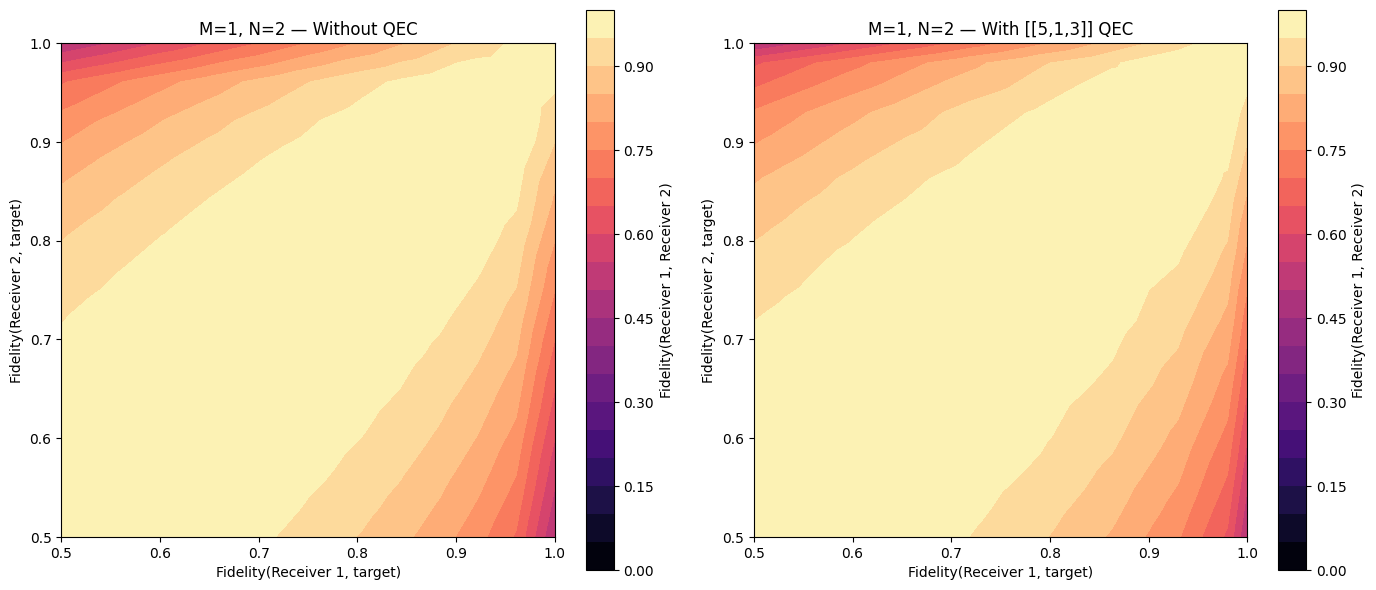

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
levels = np.linspace(0.0, 1.0, 21)

# for ax, (F1, F2, F12), title in zip(axes,[(F1_no, F2_no, F12_no), (F1_qec, F2_qec, F12_qec)],["Without QEC", "With [[5,1,3]] QEC"]):
for ax, (F1, F2, F12), title in zip(axes,[(F1_no, F2_no, F12_no), (F1_qec, F2_qec, F12_qec)],["Without QEC", "With [[5,1,3]] QEC"]):
    tcf = ax.tricontourf(F1, F2, F12, levels=levels, cmap=cm.magma, vmin=0.0, vmax=1.0)
    ax.set_xlabel("Fidelity(Receiver 1, target)")
    ax.set_ylabel("Fidelity(Receiver 2, target)")
    ax.set_title(f"M={M_c}, N={N_c} — {title}")
    ax.set_xlim(0.5, 1)
    ax.set_ylim(0.5, 1)
    ax.set_aspect("equal")
    fig.colorbar(tcf, ax=ax, label="Fidelity(Receiver 1, Receiver 2)")

plt.tight_layout()
plt.show()